In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
df=pd.DataFrame(california.data, columns=california.feature_names)
df['TARGET']=california.target

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

data=torch.from_numpy(df.values).float()
data.shape

x=data[:, :-1]
y=data[:, -1:]

print(x.shape, y.shape)

torch.Size([20640, 8]) torch.Size([20640, 1])


In [2]:
ratio = [.6, .2, .2]
train_cnt = int(data.size(0) * ratio[0])
valid_cnt = int(data.size(0) * ratio[1])
test_cnt = data.size(0) - train_cnt - valid_cnt
cnts = [train_cnt, valid_cnt, test_cnt]

print("Train %d / Valid %d / Test %d samples." %(train_cnt, valid_cnt, test_cnt))

Train 12384 / Valid 4128 / Test 4128 samples.


In [3]:
indices= torch.randperm(data.size(0))
x=torch.index_select(x, dim=0, index=indices)
y=torch.index_select(y, dim=0, index=indices)

x=list(x.split(cnts, dim=0))
y=y.split(cnts, dim=0)

for x_i, y_i in zip(x,y):
    print(x_i.size(),y_i.size())

torch.Size([12384, 8]) torch.Size([12384, 1])
torch.Size([4128, 8]) torch.Size([4128, 1])
torch.Size([4128, 8]) torch.Size([4128, 1])


### 데이터 정규화
- 학습 데이터만으로 정규화(fit) 진행
- 검증, 테스트 데이터 제외
- 학습 데이터로만 정규화한 변환 비율로 학습, 검증, 테스트 데이터를 변환
- 학습을 할 때 영향을 미치기 때문에 정규화를 함

In [4]:
scaler = StandardScaler()
scaler.fit(x[0].numpy())

x[0] = torch.from_numpy(scaler.transform(x[0].numpy())).float()
x[1] = torch.from_numpy(scaler.transform(x[1].numpy())).float()
x[2] = torch.from_numpy(scaler.transform(x[2].numpy())).float()

### 하이퍼 파라미터 설정
- 조기 종료 설정: 일정 에폭동안 성능 개선이 없으면 종료하도록 설정

In [5]:
n_epochs = 4000
batch_size = 256
print_interval = 100
early_stop = 100
# ealry_stop만큼의 기간동안 성능 개선이 없으면 종류
# early_stop이 0이면 n_epochs만틈 끝까지 학습

In [6]:
model = nn.Sequential(
    nn.Linear(x[0].size(-1), 6),
    nn.LeakyReLU(),
    nn.Linear(6, 5),
    nn.LeakyReLU(),
    nn.Linear(5, 4),
    nn.LeakyReLU(),
    nn.Linear(4, 3),
    nn.LeakyReLU(),
    nn.Linear(3, y[0].size(-1)),
)

optimizer = optim.Adam(model.parameters())

In [7]:
from copy import deepcopy

lowest_loss = np.inf
best_model = None
lowest_epoch = np.inf

- 3개의 값은 되돌리기 위해 사용

In [8]:
import time

train_history, valid_history = [], []

start = time.time()

for i in range(n_epochs):
    # Shuffle
    indices = torch.randperm(x[0].size(0))
    x_ = torch.index_select(x[0], dim=0, index=indices)
    y_ = torch.index_select(y[0], dim=0, index=indices)

    x_ = x_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0

    for x_i, y_i in zip(x_, y_): # iteraction: 12,384 // 256 + 1 = 49
        y_hat_i = model(x_i)
        loss = F.mse_loss(y_hat_i, y_i)
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()        
        train_loss += float(loss)
        
    train_loss = train_loss / len(x_) # 1 에폭당 평균 손실값

    with torch.no_grad(): # 계산 그래프 생성을 하지 않음
        #  shuffle 과정 필요 없음
        x_ = x[1].split(batch_size, dim=0)
        y_ = y[1].split(batch_size, dim=0)

        valid_loss = 0

        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = F.mse_loss(y_hat_i, y_i)

            valid_loss += loss
    valid_loss = valid_loss/ len(x_) # 1 epoch 당 평균 손실값

    # 손실곡선을 그리기 위한 손실값 저장
    train_history += [train_loss] # epoch 마다 학습 손실값 차례로 저장
    valid_history += [valid_loss] # epoch 마다 검증 손길값 차례로 저장

    # 출력
    if (i+1) % print_interval == 0:
        print('Epoch %d/%d: train loss = %.4f valid_loss=%.4f lowest_loss=%.4f elapsed_time=%.4fsec' % (
            i+1,n_epochs, train_loss, valid_loss, lowest_loss,time.time()-start))
        start = time.time()
    # 검증 손실의 최소값 찾기
    if valid_loss<=lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i+1:
            print("There is no improvement during last %d epochs." % early_stop)
            break
print("The best validation loss from epoch %d: %.4f" % (lowest_epoch + 1, lowest_loss))
model.load_state_dict(best_model)

C:\Users\legna\AppData\Local\Temp\ipykernel_8092\4203740639.py:25: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  train_loss += float(loss)


Epoch 100/4000: train loss = 0.3892 valid_loss=0.4107 lowest_loss=0.4107 elapsed_time=21.2224sec
Epoch 200/4000: train loss = 0.3745 valid_loss=0.3937 lowest_loss=0.3934 elapsed_time=21.2513sec
Epoch 300/4000: train loss = 0.3729 valid_loss=0.3904 lowest_loss=0.3895 elapsed_time=21.3658sec
Epoch 400/4000: train loss = 0.3727 valid_loss=0.3890 lowest_loss=0.3880 elapsed_time=21.2250sec
Epoch 500/4000: train loss = 0.3731 valid_loss=0.3878 lowest_loss=0.3874 elapsed_time=21.2884sec
Epoch 600/4000: train loss = 0.3724 valid_loss=0.3871 lowest_loss=0.3868 elapsed_time=21.3322sec
There is no improvement during last 100 epochs.
The best validation loss from epoch 573: 0.3868


<All keys matched successfully>

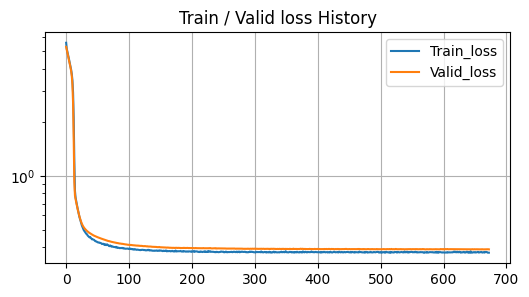

In [9]:
plot_from = 0

plt.figure(figsize=(6,3))
plt.grid(True)
plt.title("Train / Valid loss History")
plt.plot(range(plot_from, len(train_history)), train_history[plot_from:], label='Train_loss')
plt.plot(range(plot_from, len(valid_history)), valid_history[plot_from:], label='Valid_loss')
plt.yscale('log')
plt.legend()
plt.show()

In [10]:
test_loss = 0
y_hat = []

with torch.no_grad():
    x_ = x[2].split(batch_size, dim=0)
    y_ = y[2].split(batch_size, dim=0)

    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)
        loss = F.mse_loss(y_hat_i, y_i)

        test_loss += loss # Gradient is already detached.

        y_hat += [y_hat_i]

test_loss = test_loss / len(x_)
y_hat = torch.cat(y_hat, dim=0)

sorted_history = sorted(zip(train_history, valid_history),
                        key=lambda x: x[1])

print("Train loss: %.4f" % sorted_history[0][0])
print("Valid loss: %.4f" % sorted_history[0][1])
print("Test loss: %.4f" % test_loss)

Train loss: 0.3722
Valid loss: 0.3868
Test loss: 0.3915


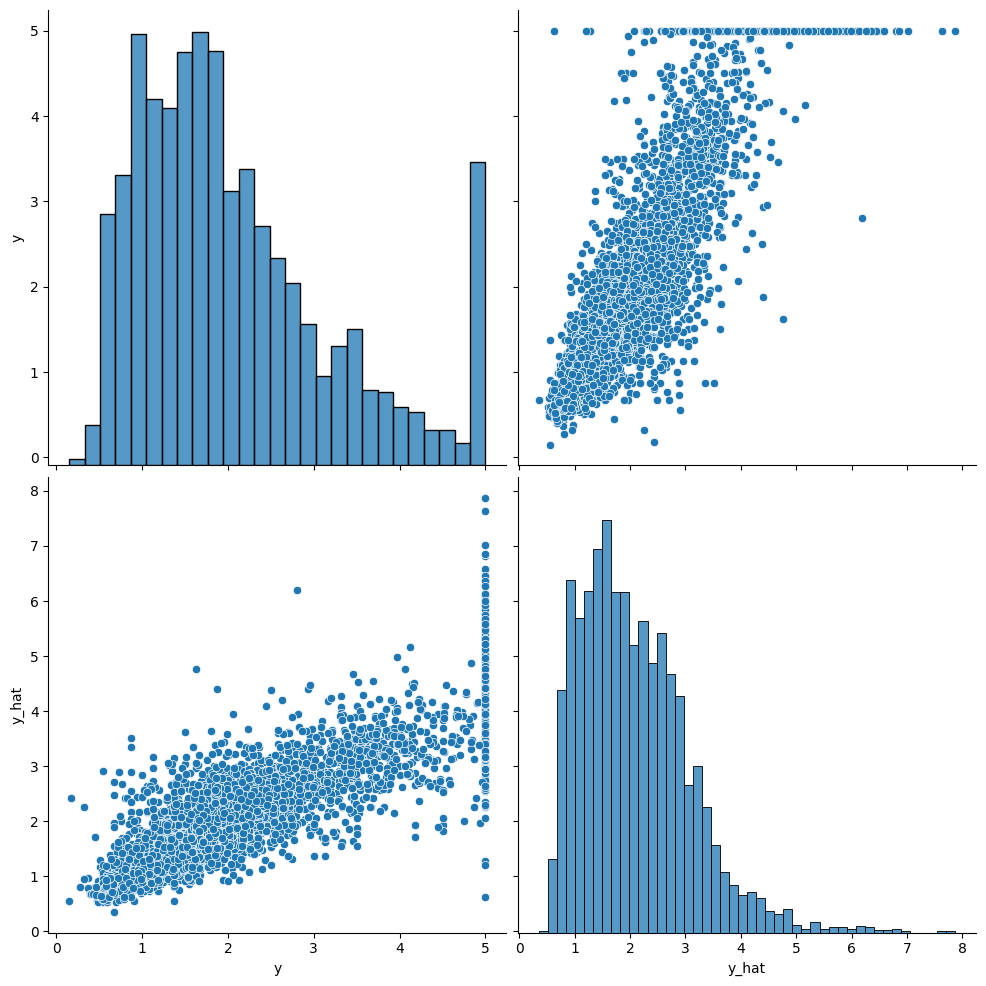

In [11]:
df = pd.DataFrame(torch.cat([y[2], y_hat], dim=1).detach().numpy(),
                  columns=["y", "y_hat"])

sns.pairplot(df, height=5)
plt.show()

# 13. 심층신경망 Ⅱ
## 1. 이진 분류

### 로지스틱 회귀
- 회귀(regression)이지만 마지막에 시그모이드를 추가함으로써 이진 분류가 되도록 함

### 심층 신경망을 활용한 이진 분류
- 로지스틱 회귀(8장 예제)에서 사용한 신경망 대신 심층신경망으로 교체
- 수식에서는 $\theta = \{{W, b\}}$ 대신 $\theta = \{{W_1, b_1, ... ,W_l, b_l\}}$
- BCE 손실함수의 미분은 체인룰을 통해 각 계층을 거슬러 역전파됨

## 2. 평가 지표

### 이진 분류 문제
- 기본: 시그모이드 함수의 결과(0~1)를 0.5 기준으로 이진 분류됨
- 필요에 따라서는 임계값을 참, 거짓의 분포로 보고 사람이 값을 결정하기도 함 $\to$ 하이퍼파라미터
  - 원자력 발전소의 방사능 누출 감지 여부
  - 전재산을 주식에 투자할 때의 투자 정책
  - 유방암 진단<br>
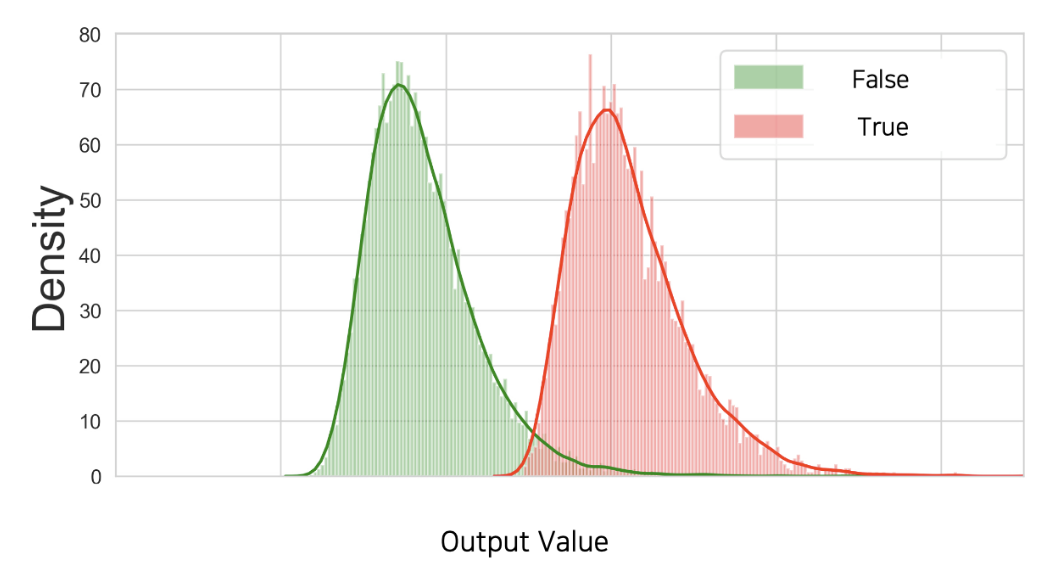
- 0.5 보다 큰 False와 0.5보다 작은 True는 에러가 발생함
  - 첫 번째 예시를 적용해보자면 True(빨간색)의 값을 방사능에 유출된 사람들이라 했을 때 0.5보다 아래인데 빨간색 범위 안에 있다면 방사능에 유출이 되었지만 유출되지 않았다고 판단하게 됨

- 혼동행렬(confusion matrix)<br>
  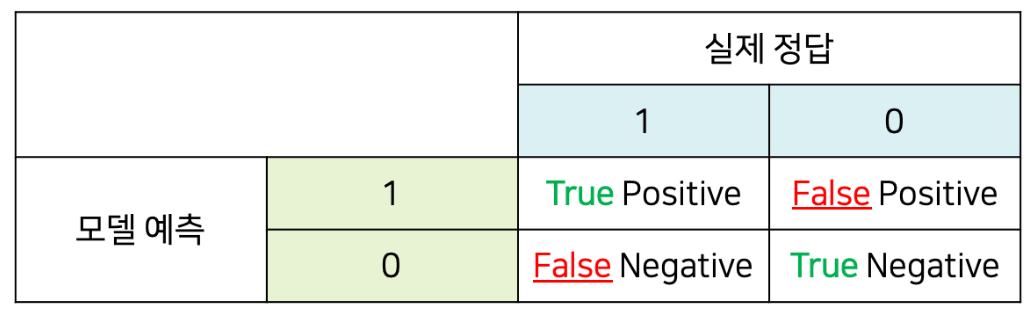

### 정확도(accuracy)
- 맞춘 것에 대한 비율<br>
  $Accuracy = \displaystyle \frac{TP + TN}{TP + FP + FN + TN}$
- 가장 널리 쓰이는 비율
- 테스트 데이터셋의 클래스가 불균형할 경우 모델 성능 부정확
- 클래스별 성능의 자세한 분석이 어려움

### 정밀도(precistion)와 재현율(recall)
- 정밀도: 노이즈(FP) 없이 얼마나 순수한 정답(TP)인지 평가<br>
  ‘모델이 양성 클래스라고 예측한 갯수’ 중에서 ‘예측 중에서 실제로 맞춘 양성 클래스 갯수’의 비율
  - 양성으로 예측한 개수(TP + FP) 중에 예측 중 실제로 맞춘 양성의 개수(TP)
- 재현율: 누락된 것(FN) 없이 원하는 정답(TP)이 얼마나 포함되었는지 평가<br>
  - ‘실제로 양성 클래스인 샘플의 갯수’ 중에서 ‘예측 중에서 실제로 맞춘 양성 클래스 갯수’의 비율<br>
  - 실제 양성 클래스 중에서 모델이 얼마나 회수했는지에 대한 비율
    - 실제로 양성인 샘플의 개수(TP + FN) 중에 예측 중 실제로 맞춘 양성의 개수(TP)<br>
    $precision = \displaystyle \frac{TP}{TP+FP}$ $Recall = \displaystyle \frac{TP}{TP+FN}$

### F1 점수
- 정밀도와 재현율은 반비례
- F1 점수: 정밀도와 재현율 양쪽을 고려한 평가지수